# Newton's Method for HIV Data in Table 14.2 of Lange (2010)

We start by visualizing the data and the contours.

In [44]:
import numpy as np
quarter = np.arange(14) + 1
deaths = np.array([0,1,2,3,1,4,9,18,23,31,20,25,37,45])

In [3]:
quarter

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [4]:
deaths

array([ 0,  1,  2,  3,  1,  4,  9, 18, 23, 31, 20, 25, 37, 45])

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

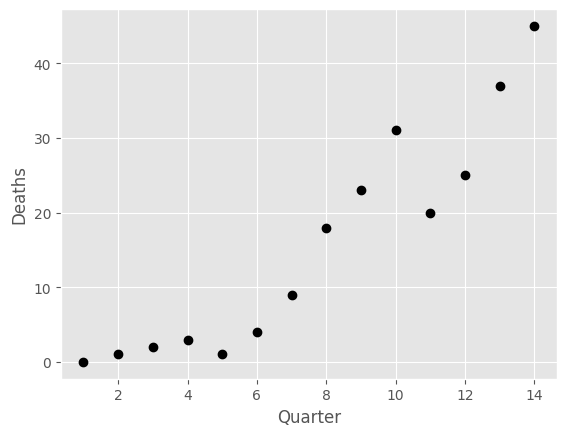

In [6]:
plt.plot(quarter, deaths, 'o', color='black');
plt.xlabel("Quarter");
plt.ylabel("Deaths");

Since `quarter` is the predictor and `deaths` is the response, we relabel these variables as x and y to make this a little more standard.

In [7]:
x = quarter
y = deaths

## Newton's Method

The model we fit is
$$Y_i \sim Poisson(\mu(X_i))$$
where
$$\mu(x_i) = e^{\theta_1 + \theta_2x_i}$$
The log likelihood is
$$ L = \sum_{i=1}^n \left(-e^{\theta_1 + \theta_2x_i} + (\theta_1 + \theta_2x_i)y_i - \log y_i !\right)$$
We code the log likelihood and plot the contours.

- 포아송 분포 : 

포아송 분포가 뭐냐면
포아송 분포는 "정해진 시간이나 공간 안에서 어떤 사건이 몇 번 일어날까?" 를 다루는 분포예요. 핵심은 개수를 세는 상황이라는 점입니다.
예를 들면:

한 시간 동안 카페에 손님이 몇 명 올까
하루에 받는 이메일이 몇 통일까
책 한 페이지에 오타가 몇 개 있을까

이런 건 0, 1, 2, 3... 처럼 0 이상의 정수로만 나와요. 키나 몸무게처럼 연속적인 값이 아니라, "셀 수 있는" 값이라는 게 특징입니다.
포아송 분포에는 모수(parameter)가 딱 하나 있는데, 보통 μ\mu
μ (뮤) 또는 λ\lambda
λ (람다)라고 씁니다. 이게 평균 발생 횟수예요. 평균적으로 손님이 시간당 10명 온다면 μ=10\mu = 10
μ=10인 거죠. 그리고 포아송 분포의 재밌는 성질은 평균과 분산이 둘 다 μ\mu
μ로 같다는 점입니다.
그럼 이 슬라이드는 무슨 얘기냐면
이제 슬라이드를 한 줄씩 풀어볼게요.
첫째 줄: Yi∼Poisson(μ(Xi))Y_i \sim \text{Poisson}(\mu(X_i))
Yi​∼Poisson(μ(Xi​))
"ii
i번째 관측값 YiY_i
Yi​(개수 데이터)가 포아송 분포를 따른다"는 뜻이에요. 그런데 평균 μ\mu
μ가 고정된 숫자가 아니라 XiX_i
Xi​(설명 변수, 예: 광고비, 온도 등)에 따라 달라지는 거예요. 즉 XiX_i
Xi​가 크면 평균 발생 횟수도 달라진다는 모델입니다.
둘째 줄: μ(xi)=eθ1+θ2xi\mu(x_i) = e^{\theta_1 + \theta_2 x_i}
μ(xi​)=eθ1​+θ2​xi​
여기서 왜 갑자기 지수함수 ee
e가 나오냐면 — 평균 μ\mu
μ는 개수의 평균이라 절대 음수가 될 수 없어요. 그런데 θ1+θ2xi\theta_1 + \theta_2 x_i
θ1​+θ2​xi​ 같은 직선 식은 음수가 나올 수 있죠. 그래서 지수함수로 한 번 감싸주면 결과가 항상 양수가 됩니다. 이게 바로 포아송 회귀(Poisson regression)의 핵심 트릭이에요. θ1,θ2\theta_1, \theta_2
θ1​,θ2​는 우리가 데이터로부터 찾아내려는 미지의 계수입니다(직선 회귀의 절편·기울기와 비슷한 역할).
셋째 줄 (로그 가능도, log likelihood):
L=∑i=1n(−eθ1+θ2xi+(θ1+θ2xi)yi−log⁡yi!)L = \sum_{i=1}^{n} \left( -e^{\theta_1 + \theta_2 x_i} + (\theta_1 + \theta_2 x_i)y_i - \log y_i! \right)L=i=1∑n​(−eθ1​+θ2​xi​+(θ1​+θ2​xi​)yi​−logyi​!)
이게 제일 무섭게 생겼지만, 의미는 단순해요. "우리가 고른 θ1,θ2\theta_1, \theta_2
θ1​,θ2​가 실제 데이터를 얼마나 잘 설명하는가" 를 점수로 나타낸 식입니다. 이 점수(LL
L)가 클수록 좋은 모델이에요.
그래서 우리의 목표는 LL
L을 최대로 만드는 θ1,θ2\theta_1, \theta_2
θ1​,θ2​를 찾는 것 — 바로 여기서 지난번에 정리한 Newton's Method가 등장합니다. LL
L이 가장 높은 봉우리(최댓값)를 찾아 올라가는 거죠.
이 식이 어떻게 나왔는지 궁금하실 텐데, 간단히만 말하면: 포아송 분포의 확률 공식에 로그를 씌우고, 모든 데이터 nn
n개에 대해 더한 것(∑\sum
∑)입니다. 로그를 씌우는 이유는 곱셈이 덧셈으로 바뀌어 미분과 계산이 훨씬 쉬워지기 때문이에요.
마지막 줄의 −log⁡yi!-\log y_i!
−logyi​! 항은 θ\theta
θ와 전혀 관계없는 상수라서, 실제로 최댓값을 찾을 때(미분할 때)는 사라집니다. 그래서 사실상 앞의 두 항만 신경 쓰면 돼요.

정리하면 이런 흐름입니다:
개수 데이터를 모델링하려고 포아송 분포를 씀 → 평균이 항상 양수여야 하니 eθ1+θ2xe^{\theta_1 + \theta_2 x}
eθ1​+θ2​x 형태로 둠 → 데이터를 가장 잘 설명하는 θ\theta
θ를 찾으려고 log likelihood LL
L을 세움 → LL
L을 최대화하려고 Newton's Method를 사용함.

In [15]:
## we ignore the -log(y!) in the loglik because it does not depend on theta
## log y : 상수항이라서 최적화 문제에서 무시할 수 있다.
def loglike(theta1,theta2,x,y):
    s = -np.exp(theta1 + x*theta2)
    return np.sum(s + (theta1 + theta2*x)*y)

In [9]:
## see https://jakevdp.github.io/PythonDataScienceHandbook/04.04-density-and-contour-plots.html
## on meshgrid function for producing grid as input for contour plot
theta1g = np.linspace(0.0,1.0,100)
theta2g = np.linspace(0.2,0.3,100)

In [10]:
theta1g, theta2g = np.meshgrid(theta1g, theta2g)
theta1g.shape

(100, 100)

In [11]:
# All pairs in grid
XYpairs = np.vstack([ theta1g.reshape(-1), theta2g.reshape(-1) ])
XYpairs

array([[0.        , 0.01010101, 0.02020202, ..., 0.97979798, 0.98989899,
        1.        ],
       [0.2       , 0.2       , 0.2       , ..., 0.3       , 0.3       ,
        0.3       ]], shape=(2, 10000))

In [12]:
Z = np.apply_along_axis(lambda z: loglike(z[0],z[1],x,y),0,XYpairs)
Z = Z.reshape((100,100))

We draw contour and 3-D plots of the log likelihood.

In [13]:
theta1t, theta2t = 0.3396, 0.2565   # truemaximizer

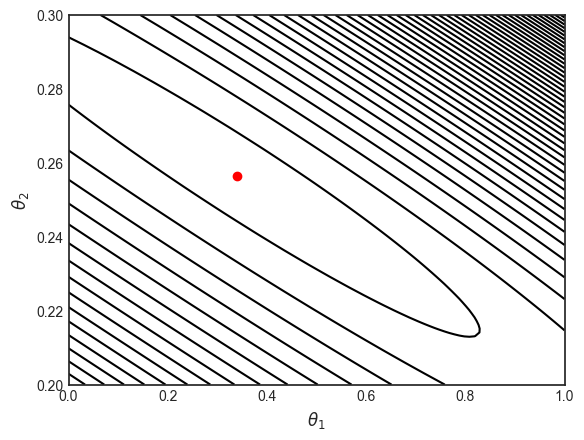

In [14]:
### PLOT 1: contours
plt.style.use('seaborn-v0_8-white')
plt.contour(theta1g, theta2g, Z,50, colors='black');
plt.plot(theta1t,theta2t,'o',color='red');
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$');


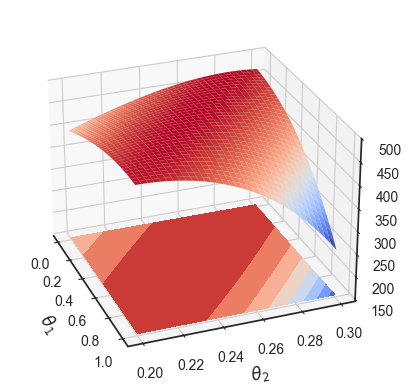

In [16]:
### PLOT 2: 3-D
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Create a surface plot and projected filled contour plot under it.
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(theta1g, theta2g, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.coolwarm)

cset = ax.contourf(theta1g, theta2g, Z, zdir='z', offset=150, cmap=cm.coolwarm)

ax.set_zlim(145,500)
##ax.set_zticks(np.linspace(0,0.2))

# Adjust the limits, ticks and view angle
##ax.set_zlim(-0.15,0.2)
##ax.set_zticks(np.linspace(0,0.2,5))
ax.view_init(27, -21)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$');

plt.show()

짙은 빨간색 중에 최대화되는 지점이 있음

## Gradient and Hessian Functions

We use Newton's method to maximize the log likelihood $L$. The gradient is
$$ dL = \left(\sum -e^{\theta_1 + \theta_2x_i} + y_i,\sum - x_i e^{\theta_1 + \theta_2} + x_iy_i\right)$$
and the Hessian is
$$d^2L = \begin{pmatrix}
\sum -e^{\theta_1 + \theta_2x_i} & \sum -x_i e^{\theta_1 + \theta_2x_i}\\
\sum -x_i e^{\theta_1 + \theta_2x_i} & \sum -x_i^2 e^{\theta_1 + \theta_2x_i}\\
\end{pmatrix}$$
To prevent Newton's method from overshooting the maximum, we implement step halving in Newton's method.

Further examination of $dL$ and $d^2L$ reveals that the following pseudocode can be used to compute the gradient and the Hessian. Define
$$s_i = -e^{\theta_1 + \theta_2x_i}$$
Then
$$dL = (sum(s + y),sum(sx + xy))$$
and
$$d^2L = \begin{pmatrix}
sum(s)& sum(sx)\\
sum(sx) & sum(sx^2)\\
\end{pmatrix}$$

기존 L 함수  
$$ L = \sum_{i=1}^n \left(-e^{\theta_1 + \theta_2x_i} + (\theta_1 + \theta_2x_i)y_i - \log y_i !\right)$$

In [17]:
def dloglike(theta1,theta2,x,y):
    s = -np.exp(theta1 + x*theta2)
    return np.array([np.sum(s + y),np.sum(x*s + x*y)])

In [20]:
# Hessian of loglikelihood
def d2loglike(theta1,theta2,x,y):
    s = -np.exp(theta1 + x*theta2)
    cross = np.sum(s*x)
    return np.array([np.sum(s),cross,cross,np.sum(s*np.power(x,2))]).reshape(2,2)  # reshape(2,2) : 4개의 원소를 2행 2열의 행렬로 변환한다는 의미

Now run Newton with step halving.

In [ ]:
## initial values
theta1c = 0
theta2c = 0
Niter = 20. # number of iterations 
for jj in np.arange(Niter): # 통상적으로는 parameter 값이나 loglikelihood의 변화량이 충분히 작아질 때까지 반복한다. (알고리즘이 수렴했다고 판단함)
    print("theta1: " + str(theta1c) + " theta2: " + str(theta2c))
    g = dloglike(theta1c,theta2c,x,y).reshape((2,1))  # gradient of loglikelihood : column vector
    h = d2loglike(theta1c,theta2c,x,y) # Hessian of loglikelihood : 2 by 2 matrix   
    a,b = np.matmul(np.linalg.inv(h),g) # hesian의 역행렬과 gradient의 곱 : Newton step : 2 by 1 vector
    c = 1.0 # step size ( step-halving will be used to ensure increase in loglikelihood )
    half = True
    while half:
        t1 = theta1c - c*a
        t2 = theta2c - c*b
        if loglike(t1,t2,x,y) < loglike(theta1c,theta2c,x,y): # loglikelihood가 증가하지 않으면 > overshooting 발생 > step-halving (업데이트를 절반으로 줄임) 
            print("halved")
            c = c / 2.0
        else:
            theta1c = t1 
            theta2c = t2
            half = False
            
# loglikelihood의 최적화 문제에서, Newton's method는 loglikelihood의 최대값을 찾기 위해서 사용되는 방법이다. (local인지 global인지에 대한 보장은 없다.)

theta1: 0 theta2: 0
halved
halved
halved
theta1: [-1.30769231] theta2: [0.41840659]
theta1: [0.64560322] theta2: [0.24013801]
theta1: [0.37437854] theta2: [0.25415247]
theta1: [0.34003443] theta2: [0.25649294]
theta1: [0.33963397] theta2: [0.25652359]
theta1: [0.33963392] theta2: [0.25652359]
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33963392] theta2: [0.25652359]
halved
halved
halved
halved
halved
theta1: [0.33

The algorithm converged in a small number of steps. The small changes in parameter values and the large number of step halving in later iterations tells us this.


**Exercise:** Rewrite the above code to terminate after converence, rather than specifying a specific number of iterations.

In [23]:
## initial values
theta1c = 0
theta2c = 0
Niter = 20. # number of iterations 
tol = 1e-6 # tolerance for convergence 
for jj in np.arange(Niter): # 통상적으로는 parameter 값이나 loglikelihood의 변화량이 충분히 작아질 때까지 반복한다. (알고리즘이 수렴했다고 판단함)
    print("theta1: " + str(theta1c) + " theta2: " + str(theta2c))
    g = dloglike(theta1c,theta2c,x,y).reshape((2,1))  # gradient of loglikelihood : column vector
    h = d2loglike(theta1c,theta2c,x,y) # Hessian of loglikelihood : 2 by 2 matrix   
    a,b = np.matmul(np.linalg.inv(h),g) # hesian의 역행렬과 gradient의 곱 : Newton step : 2 by 1 vector
    c = 1.0 # step size ( step-halving will be used to ensure increase in loglikelihood )
    half = True 
    while half:
        t1 = theta1c - c*a
        t2 = theta2c - c*b
        if loglike(t1,t2,x,y) < loglike(theta1c,theta2c,x,y): # loglikelihood가 증가하지 않으면 > overshooting 발생 > step-halving (업데이트를 절반으로 줄임) 
            print("halved")
            c = c / 2.0
        else:
            half = False
    if (np.sqrt((t1 - theta1c) **2 + (t2 - theta2c) **2) < tol) :  # parameter 값의 변화량이 충분히 작아지면 > 알고리즘이 수렴했다고 판단 > 반복 종료
        break
     
    theta1c = t1 
    theta2c = t2
            
# loglikelihood의 최적화 문제에서, Newton's method는 loglikelihood의 최대값을 찾기 위해서 사용되는 방법이다. (local인지 global인지에 대한 보장은 없다.)

theta1: 0 theta2: 0
halved
halved
halved
theta1: [-1.30769231] theta2: [0.41840659]
theta1: [0.64560322] theta2: [0.24013801]
theta1: [0.37437854] theta2: [0.25415247]
theta1: [0.34003443] theta2: [0.25649294]
theta1: [0.33963397] theta2: [0.25652359]


## Numerically Approximating Hessians and Gradients

One can check the coded Hessians are correct by numerically approximating the Hessian using only the log likelihood function.  
For python these numerical differentiation tools are available in `numdifftools` package.

These tools are also useful for likelihoods where analytic gradients and Hessians are not available.

단, 수치적으로 계산하면 속도는 느려진다.

In [24]:
import sys
!{sys.executable} -m pip install numdifftools


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [41]:
import numdifftools as nd

In [42]:
def loglike_wrap(thetas):
    return loglike(thetas[0],thetas[1],x,y)

In [43]:
out = nd.Hessian(loglike_wrap)([theta1c[0],theta2c[0]]) # 목적함수, 계산 위치 

TypeError: 'int' object is not subscriptable

In [40]:
theta1c[0]

TypeError: 'int' object is not subscriptable

In [28]:
out

array([[  -219.00000142,  -2404.000008  ],
       [ -2404.000008  , -28447.90285661]])

In [31]:
V_approx = np.linalg.inv(out)
V_approx

array([[-0.06309492,  0.00533186],
       [ 0.00533186, -0.00048572]])

In [32]:
V = np.linalg.inv(h)
V

array([[-0.06309492,  0.00533186],
       [ 0.00533186, -0.00048572]])

In [33]:
V[0,0]

np.float64(-0.06309491557074574)

In [34]:
V_approx[0,0]

np.float64(-0.06309491556162644)

One could numerically approximate the Hessian and gradient at every step of Newton's method. The two disadvantages are that the approximation may not be accurate (although the above approximation looked pretty good) and the speed may be slower. We compare the time it takes to numerically approximate a Hessian to the time it takes to compute it analytically now.

In [35]:
%timeit out = nd.Hessian(loglike_wrap)([theta1c[0],theta2c[0]])

902 μs ± 26.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
%timeit d2loglike(theta1c[0],theta2c[0],x,y)

**Exercise:** Code Newton's method with numerically approximated gradients and Hessians and compare the speed of this new version to the version presented here with analytic gradients and Hessians.

**Exercise:** Write a function `Newton` which takes arguments f, df, and d2f (function to optimize, gradient, and hessian) as well as data X and returns the maximizer. The function could also take as arguments number of iterations. You could make the df and d2f arguments optional and numerically approximate them if they are missing.